In [1]:
# Install sentence-transformers if not already installed
!pip install -q sentence-transformers matplotlib seaborn

# Step 1: Write 10 sentences across 3 topics
sentences = [
    # Cricket
    "The batsman scored a century in the final match.",
    "The bowler delivered a perfect yorker to dismiss the player.",
    "The crowd cheered loudly as the team won the trophy.",
    "The fielder made a stunning catch near the boundary.",

    # Cooking
    "The chef prepared a delicious pasta with fresh herbs.",
    "Baking bread requires patience and precise measurements.",
    "The aroma of spices filled the kitchen while cooking curry.",

    # Cybersecurity
    "Strong passwords are essential to protect online accounts.",
    "Phishing attacks often trick users into revealing sensitive data.",
    "Encryption ensures that information remains secure during transmission."
]

len(sentences)


10

In [2]:
# Step 2: Generate embeddings using sentence-transformers
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

embeddings.shape


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

torch.Size([10, 384])

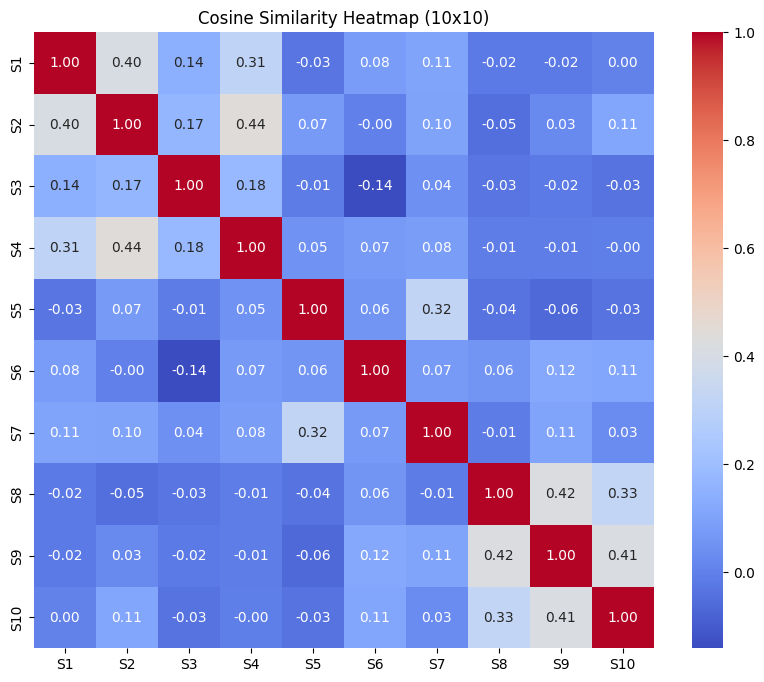

In [3]:
# Step 3: Compute cosine similarity matrix
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings.cpu().numpy())

# Display as heatmap
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=[f"S{i+1}" for i in range(len(sentences))],
            yticklabels=[f"S{i+1}" for i in range(len(sentences))])
plt.title("Cosine Similarity Heatmap (10x10)")
plt.show()


In [4]:
# Step 4: Query sentence similarity
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

# Compute similarity with all sentences
scores = cosine_similarity([query_embedding.cpu().numpy()], embeddings.cpu().numpy())[0]

# Get top 2 most similar sentences
top_indices = np.argsort(scores)[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:")
for idx in top_indices:
    print(f"Sentence: {sentences[idx]} | Similarity: {scores[idx]:.4f}")


Query: The bowler took three wickets in one over

Top 2 most similar sentences:
Sentence: The batsman scored a century in the final match. | Similarity: 0.5679
Sentence: The bowler delivered a perfect yorker to dismiss the player. | Similarity: 0.5265
